In [2]:
# ==========================================================
# 📘 GRU Model Comparison on IMDB Sentiment Classification
# ==========================================================

# ✅ STEP 1: Setup
!pip install tensorflow matplotlib scikit-learn --quiet

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, LSTM, Dense, Dropout, Bidirectional, Layer
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# ✅ STEP 2: Configuration
# ==========================================================
DATASET = 'imdb'
MAX_FEATURES = 20000   # top most frequent words
MAXLEN = 200           # sequence length
EMBED_DIM = 128
BATCH_SIZE = 128
EPOCHS = 3             # increase to 5–10 for better comparison
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)

# ==========================================================
# ✅ STEP 3: Load and Preprocess Data
# ==========================================================
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)
x_train = pad_sequences(x_train, maxlen=MAXLEN, padding='pre', truncating='pre')
x_test = pad_sequences(x_test, maxlen=MAXLEN, padding='pre', truncating='pre')

# validation split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, random_state=RANDOM_SEED)

print("Train shape:", x_train.shape, "Val shape:", x_val.shape, "Test shape:", x_test.shape)

# ==========================================================
# ✅ STEP 4: Define a Simple Attention Layer
# ==========================================================
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight',
                                 shape=(input_shape[-1],),
                                 initializer='random_normal',
                                 trainable=True)
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        e = K.tanh(inputs)
        score = K.dot(e, K.expand_dims(self.W))
        attention_weights = K.softmax(score, axis=1)
        attention_weights = K.expand_dims(attention_weights)
        context_vector = attention_weights * inputs
        context_vector = K.sum(context_vector, axis=1)
        return context_vector

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])

# ==========================================================
# ✅ STEP 5: Build Different GRU/LSTM Models
# ==========================================================
def build_simple_gru():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
        GRU(128),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_stacked_gru():
    inputs = Input(shape=(MAXLEN,))
    x = Embedding(MAX_FEATURES, EMBED_DIM)(inputs)
    x = GRU(128, return_sequences=True)(x)
    x = GRU(64)(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, out)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_bidirectional_gru():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
        Bidirectional(GRU(128)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_gru_attention():
    inputs = Input(shape=(MAXLEN,))
    x = Embedding(MAX_FEATURES, EMBED_DIM)(inputs)
    x = GRU(128, return_sequences=True)(x)

    # Apply attention layer to collapse the time dimension
    att = SimpleAttention()(x)

    # Optional dropout and dense output
    x = Dropout(0.3)(att)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, out)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm_baseline():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
        LSTM(128),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ==========================================================
# ✅ STEP 6: Train and Compare Models
# ==========================================================
models = {
    'Simple_GRU': build_simple_gru(),
    'Stacked_GRU': build_stacked_gru(),
    'Bidirectional_GRU': build_bidirectional_gru(),
    'GRU_Attention': build_gru_attention(),
    'LSTM_baseline': build_lstm_baseline()
}

results = []
histories = {}
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

for name, model in models.items():
    print(f"\n🚀 Training: {name}")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=2
    )
    histories[name] = history
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results.append({'Model': name, 'Test_Loss': loss, 'Test_Accuracy': acc})
    print(f"✅ {name}: Test Accuracy = {acc:.4f}")

results_df = pd.DataFrame(results).sort_values('Test_Accuracy', ascending=False)
print("\n🏁 Final Comparison Results:")
print(results_df)

# ==========================================================
# ✅ STEP 7: Plot Training Curves
# ==========================================================
for name, h in histories.items():
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], label='Train')
    plt.plot(h.history['val_accuracy'], label='Val')
    plt.title(f"{name} - Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], label='Train')
    plt.plot(h.history['val_loss'], label='Val')
    plt.title(f"{name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================================
# ✅ STEP 8: Save Results
# ==========================================================
results_df.to_csv("gru_comparison_results.csv", index=False)
print("\n📁 Results saved as gru_comparison_results.csv")


Train shape: (21250, 200) Val shape: (3750, 200) Test shape: (25000, 200)

🚀 Training: Simple_GRU
Epoch 1/3
167/167 - 112s - 670ms/step - accuracy: 0.7272 - loss: 0.5181 - val_accuracy: 0.8480 - val_loss: 0.3539
Epoch 2/3
167/167 - 109s - 650ms/step - accuracy: 0.8962 - loss: 0.2568 - val_accuracy: 0.8475 - val_loss: 0.3541
Epoch 3/3
167/167 - 142s - 849ms/step - accuracy: 0.9314 - loss: 0.1821 - val_accuracy: 0.8112 - val_loss: 0.4781
✅ Simple_GRU: Test Accuracy = 0.8469

🚀 Training: Stacked_GRU
Epoch 1/3
167/167 - 182s - 1s/step - accuracy: 0.7486 - loss: 0.4893 - val_accuracy: 0.8237 - val_loss: 0.4827
Epoch 2/3
167/167 - 199s - 1s/step - accuracy: 0.8918 - loss: 0.2769 - val_accuracy: 0.8408 - val_loss: 0.3737
Epoch 3/3
167/167 - 172s - 1s/step - accuracy: 0.9293 - loss: 0.1937 - val_accuracy: 0.8285 - val_loss: 0.4799
✅ Stacked_GRU: Test Accuracy = 0.8345

🚀 Training: Bidirectional_GRU
Epoch 1/3
167/167 - 220s - 1s/step - accuracy: 0.7277 - loss: 0.5308 - val_accuracy: 0.8365 - va

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 200, 1)

Train shape: (21250, 200), Val shape: (3750, 200), Test shape: (25000, 200)

🚀 Training: Simple_GRU
Epoch 1/3
167/167 - 114s - 683ms/step - accuracy: 0.7411 - loss: 0.5048 - val_accuracy: 0.8165 - val_loss: 0.4128
Epoch 2/3
167/167 - 111s - 667ms/step - accuracy: 0.8581 - loss: 0.3314 - val_accuracy: 0.8539 - val_loss: 0.3570
Epoch 3/3
167/167 - 116s - 692ms/step - accuracy: 0.9255 - loss: 0.1955 - val_accuracy: 0.8560 - val_loss: 0.4704
✅ Simple_GRU: Test Accuracy = 0.8502

🚀 Training: Stacked_GRU
Epoch 1/3
167/167 - 183s - 1s/step - accuracy: 0.7252 - loss: 0.5321 - val_accuracy: 0.8168 - val_loss: 0.4127
Epoch 2/3
167/167 - 202s - 1s/step - accuracy: 0.8811 - loss: 0.2907 - val_accuracy: 0.8581 - val_loss: 0.3634
Epoch 3/3
167/167 - 175s - 1s/step - accuracy: 0.9292 - loss: 0.1908 - val_accuracy: 0.8275 - val_loss: 0.5348
✅ Stacked_GRU: Test Accuracy = 0.8500

🚀 Training: Bidirectional_GRU
Epoch 1/3
167/167 - 221s - 1s/step - accuracy: 0.7538 - loss: 0.4869 - val_accuracy: 0.8160 - 

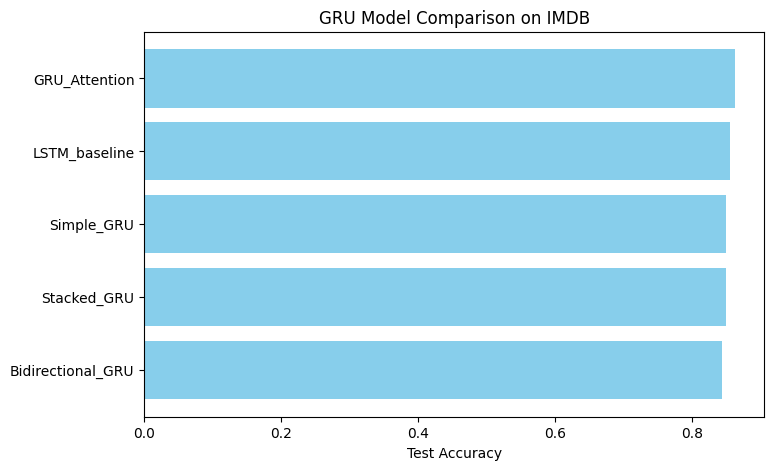


📁 Results saved as gru_comparison_results.csv


In [3]:
# ==========================================================
# 📘 GRU Model Comparison on IMDB Sentiment Dataset (Final Fixed Version)
# ==========================================================

!pip install tensorflow matplotlib scikit-learn --quiet

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, LSTM, Dense, Dropout, Bidirectional, Layer
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# ✅ STEP 1: Configuration
# ==========================================================
MAX_FEATURES = 20000   # top most frequent words
MAXLEN = 200           # sequence length
EMBED_DIM = 128
BATCH_SIZE = 128
EPOCHS = 3
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)

# ==========================================================
# ✅ STEP 2: Load and Preprocess IMDB Dataset
# ==========================================================
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)
x_train = pad_sequences(x_train, maxlen=MAXLEN, padding='pre', truncating='pre')
x_test = pad_sequences(x_test, maxlen=MAXLEN, padding='pre', truncating='pre')
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, random_state=RANDOM_SEED)
print(f"Train shape: {x_train.shape}, Val shape: {x_val.shape}, Test shape: {x_test.shape}")

# ==========================================================
# ✅ STEP 3: Define Attention Layer
# ==========================================================
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)  # (batch, time, 1)
        e = K.squeeze(e, axis=-1)  # (batch, time)
        alpha = K.softmax(e)  # attention weights
        alpha = K.expand_dims(alpha, axis=-1)  # (batch, time, 1)
        context = x * alpha
        context = K.sum(context, axis=1)  # (batch, features)
        return context

# ==========================================================
# ✅ STEP 4: Define All Models
# ==========================================================
def build_simple_gru():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
        GRU(128),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_stacked_gru():
    inputs = Input(shape=(MAXLEN,))
    x = Embedding(MAX_FEATURES, EMBED_DIM)(inputs)
    x = GRU(128, return_sequences=True)(x)
    x = GRU(64)(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, out)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_bidirectional_gru():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
        Bidirectional(GRU(128)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_gru_attention():
    inputs = Input(shape=(MAXLEN,))
    x = Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN)(inputs)
    x = GRU(128, return_sequences=True)(x)
    x = SimpleAttention()(x)  # Apply attention to reduce time dimension
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm_baseline():
    model = Sequential([
        Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
        LSTM(128),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ==========================================================
# ✅ STEP 5: Train and Evaluate All Models
# ==========================================================
models = {
    'Simple_GRU': build_simple_gru(),
    'Stacked_GRU': build_stacked_gru(),
    'Bidirectional_GRU': build_bidirectional_gru(),
    'GRU_Attention': build_gru_attention(),
    'LSTM_baseline': build_lstm_baseline()
}

results = []
histories = {}
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

for name, model in models.items():
    print(f"\n🚀 Training: {name}")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=2
    )
    histories[name] = history
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results.append({'Model': name, 'Test_Loss': loss, 'Test_Accuracy': acc})
    print(f"✅ {name}: Test Accuracy = {acc:.4f}")

results_df = pd.DataFrame(results).sort_values('Test_Accuracy', ascending=False)
print("\n🏁 Final Model Comparison:\n", results_df)

# ==========================================================
# ✅ STEP 6: Visualization
# ==========================================================
plt.figure(figsize=(8,5))
plt.barh(results_df['Model'], results_df['Test_Accuracy'], color='skyblue')
plt.xlabel('Test Accuracy')
plt.title('GRU Model Comparison on IMDB')
plt.gca().invert_yaxis()
plt.show()

results_df.to_csv("gru_comparison_results.csv", index=False)
print("\n📁 Results saved as gru_comparison_results.csv")
